# Boozer Spectrum

## What you will learn
How Boozer coordinates translate an equilibrium into Fourier modes that define symmetry objectives.

## Codes used
`booz_xform_jax` in research mode; cached Boozer-like spectrum by default.

## Run mode
This notebook uses RUN_MODE = "cached" by default. Allowed values are "tiny", "cached", and "research".

## Expected outputs
`02_boozer_contour.png`, `02_boozer_spectrum.png`, and a scalar symmetry residual.

## What this teaches

The object is the Boozer spectrum: a compact table of field-strength modes that an optimizer can penalize.

## What this does not prove

It does not prove that the cached modes came from a fresh Boozer transform of the current equilibrium.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "sos2026").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Project root: repository root detected")

Project root: repository root detected


In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected. Keep RUN_MODE='cached' first; install requirements-colab.txt from the cloned repo if needed.")
else:
    print("Local runtime detected.")

Local runtime detected.


In [3]:
RUN_MODE = "cached"  # allowed: "tiny", "cached", "research"
print(f"RUN_MODE = {RUN_MODE}")

RUN_MODE = cached


In [4]:
import importlib
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False})

from sos2026.paths import PROJECT_ROOT, DATA_DIR, CACHE_DIR, FIGURE_DIR, MOVIE_DIR, ensure_directories
ensure_directories()
print("Figures:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("Cached data:", CACHE_DIR.relative_to(PROJECT_ROOT))

Figures: assets/figures
Cached data: data/cached


## 1. Concept: Boozer coordinates are metric coordinates

Many stellarator objectives are easiest to state in Boozer coordinates because the magnetic-field strength spectrum exposes symmetry-preserving and symmetry-breaking modes.

In [5]:
from sos2026.boozer_helpers import synthetic_boozer_modes, compute_boozer_grid, symmetry_residual
from sos2026.plotting import plot_boozer_contour, plot_boozer_spectrum, savefig, caption

## 2. Load a cached spectrum

The cached modes are labeled educational data. They are structured to show the reading pattern students need before using real transforms.

In [6]:
modes = synthetic_boozer_modes("hsx")
pd.DataFrame({"m": modes["m"], "n": modes["n"], "Bmn/B00": modes["bmn"]})

,m,n,Bmn/B00
0,0,0,1.000
1,1,4,0.090
2,2,8,0.030
3,3,12,0.012
4,1,3,0.020
5,2,7,0.014
6,3,11,0.008


## 3. Reconstruct `B(theta,zeta)`

The field-strength contour is a visual diagnostic. Clean banding suggests the intended symmetry is dominant.

Caption: bands aligned with the intended symmetry are a visual check before scalar objectives.


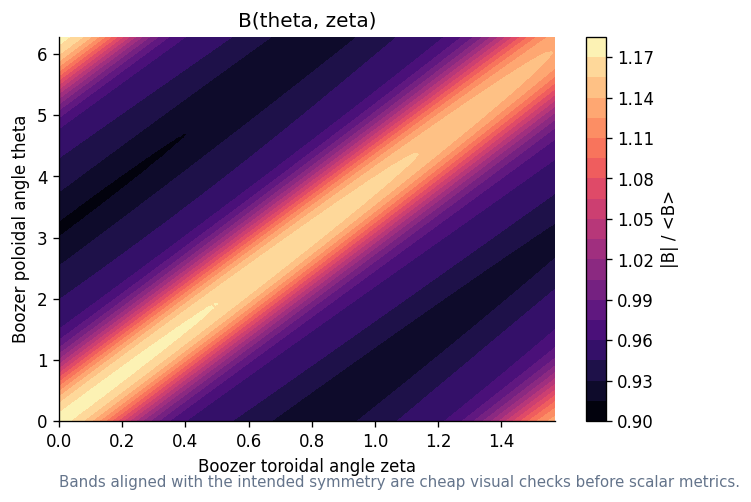

In [7]:
theta, zeta, B = compute_boozer_grid(modes)
plot_boozer_contour(theta, zeta, B)
print("Caption: bands aligned with the intended symmetry are a visual check before scalar objectives.")

## 4. Plot the spectrum

The heatmap makes off-symmetry modes easy to identify and penalize.

Symmetry-breaking residual proxy: 0.241
Caption: the optimizer can turn selected off-line modes into a scalar residual.


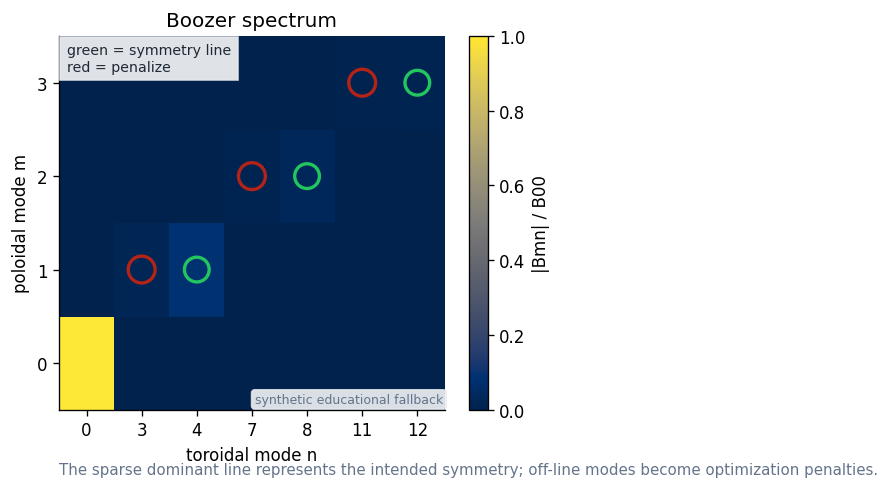

In [8]:
plot_boozer_spectrum(modes)
residual = symmetry_residual(modes)
print(f"Symmetry-breaking residual proxy: {residual:.3f}")
print("Caption: the optimizer can turn selected off-line modes into a scalar residual.")

## 5. Perturb one bad mode

A useful class exercise is to edit one mode and immediately see the contour and scalar residual change.

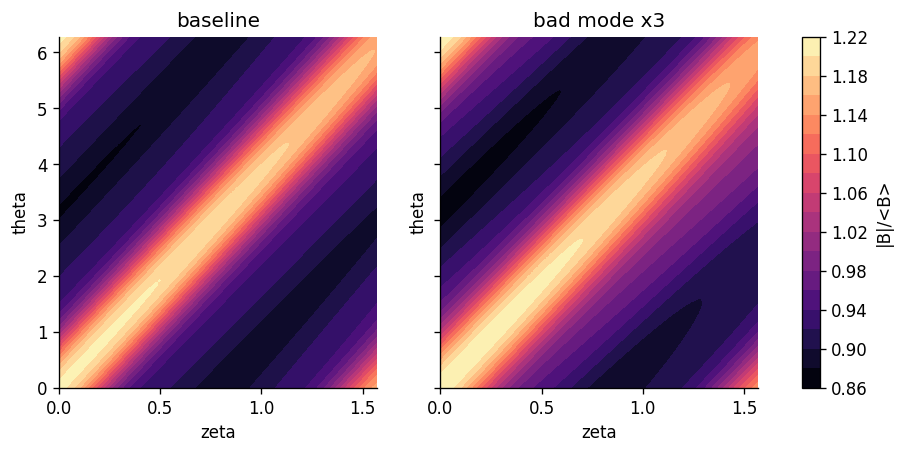

baseline residual 0.24137931034482757
perturbed residual 0.3831775700934579
Caption: increasing a symmetry-breaking mode visibly damages the contour and residual.


In [9]:
perturbed = {k: np.array(v).copy() if hasattr(v, "__len__") and not isinstance(v, str) else v for k, v in modes.items()}
perturbed["bmn"][4] *= 3.0
theta2, zeta2, B2 = compute_boozer_grid(perturbed)
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.8), sharex=True, sharey=True)
for ax, data, title in zip(axes, [B, B2], ["baseline", "bad mode x3"]):
    im = ax.contourf(zeta, theta, data, levels=20, cmap="magma")
    ax.set_title(title)
    ax.set_xlabel("zeta")
    ax.set_ylabel("theta")
fig.colorbar(im, ax=axes.ravel().tolist(), label="|B|/<B>")
fig.savefig(FIGURE_DIR / "02_bad_mode_perturbation.png", dpi=160, bbox_inches="tight")
plt.show()
print("baseline residual", symmetry_residual(modes))
print("perturbed residual", symmetry_residual(perturbed))
print("Caption: increasing a symmetry-breaking mode visibly damages the contour and residual.")

## 6. Define a compact objective

The simplest teaching objective is a normalized sum of bad-mode amplitudes. Research objectives may weight modes by physics sensitivity.

In [10]:
mode_table = pd.DataFrame({"m": modes["m"], "n": modes["n"], "bmn": modes["bmn"]})
mode_table["preserve"] = mode_table["n"] % modes["nfp"] == 0
mode_table["penalty"] = np.where(mode_table["preserve"], 0.0, mode_table["bmn"].abs())
mode_table

,m,n,bmn,preserve,penalty
0,0,0,1.000,True,0.000
1,1,4,0.090,True,0.000
2,2,8,0.030,True,0.000
3,3,12,0.012,True,0.000
4,1,3,0.020,False,0.020
5,2,7,0.014,False,0.014
6,3,11,0.008,False,0.008


## 7. Research-mode hook

`booz_xform_jax` can transform a real VMEC `wout` file. That is the right next step when runtime and API details are verified.

In [11]:
if RUN_MODE == "research":
    from booz_xform_jax import Booz_xform
    print("Research sketch: bx = Booz_xform(); bx.read_wout(...); bx.register_surfaces([...]); bx.run().")
else:
    print("Cached mode: using the labeled spectrum fallback.")

Cached mode: using the labeled spectrum fallback.


## 8. Failure mode

A Boozer spectrum is only as trustworthy as the input equilibrium, surface selection, and transform resolution. Do not optimize a noisy transform without a convergence check.

In [12]:
resolution_checks = pd.DataFrame({
    "check": ["surface choice", "mode truncation", "transform convergence", "symmetry target", "mode weights"],
    "why_it_matters": ["edge and core can rank differently", "missing modes hide errors", "numerical noise can look physical", "QA/QH/QI differ", "physics sensitivity is not uniform"],
})
resolution_checks

,check,why_it_matters
0,surface choice,edge and core can rank differently
1,mode truncation,missing modes hide errors
2,transform convergence,numerical noise can look physical
3,symmetry target,QA/QH/QI differ
4,mode weights,physics sensitivity is not uniform


<!-- SOS2026_EXTRA_CLASSROOM_EXAMPLE -->

## Additional classroom example

This final example adds a second view of the same lesson. The goal is to make the GitHub-rendered notebook useful even before a student runs it locally.

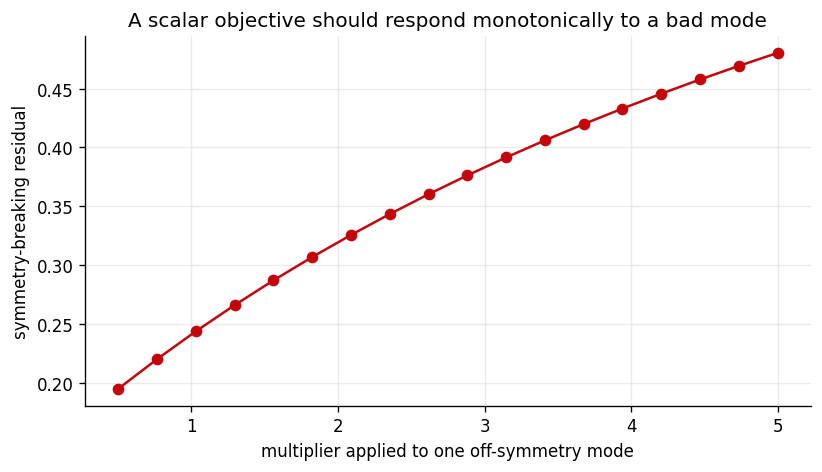

Caption: this sensitivity scan checks that the teaching residual penalizes the intended off-symmetry mode.


In [13]:
from sos2026.boozer_helpers import synthetic_boozer_modes, symmetry_residual
base = synthetic_boozer_modes("hsx")
factors = np.linspace(0.5, 5.0, 18)
res = []
for factor in factors:
    trial = {k: np.array(v).copy() if hasattr(v, "__len__") and not isinstance(v, str) else v for k, v in base.items()}
    trial["bmn"][4] *= factor
    res.append(symmetry_residual(trial))
fig, ax = plt.subplots(figsize=(7.8, 4.0))
ax.plot(factors, res, color="#c5050c", marker="o")
ax.set_xlabel("multiplier applied to one off-symmetry mode")
ax.set_ylabel("symmetry-breaking residual")
ax.set_title("A scalar objective should respond monotonically to a bad mode")
ax.grid(alpha=0.25)
plt.show()
print("Caption: this sensitivity scan checks that the teaching residual penalizes the intended off-symmetry mode.")

## Output review prompt

Before using this notebook in class, check that the final plot has a clear title, readable axes, and a caption that states what design decision it supports.

## Try this
Circle the modes that violate the intended symmetry, then increase one of them and rerun the residual.

## Expected qualitative answer
The off-symmetry mode increases the residual and distorts the `B(theta,zeta)` banding.

## Research extension
Run `booz_xform_jax` on the fetched HSX or W7-X `wout` and compare the real mode table to this cached example.